# Tiny Absurd MILP Formulation Checks

This notebook validates the mathematical formulation with intentionally tiny instances. The goal is not performance. The goal is to check whether each modeling component behaves as expected in cases where the correct outcome can be reasoned by inspection.

Each case follows the same pattern:

1. Define a tiny instance.
2. State the expected behavior.
3. Solve the MILP.
4. Inspect schedule/resource/energy outputs.
5. Record pass/fail in a summary table.

These tests complement unit tests. They are designed for formulation discussion with a supervisor or colleague.


In [1]:
from __future__ import annotations

from dataclasses import replace
from pathlib import Path
import sys
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
import pytest

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import ModelConfig
from src.evaluation.metrics import compute_summary_metrics
from src.evaluation.results import extract_cluster_hourly_results, extract_hourly_results, extract_schedule
from src.milp.gurobi_model import build_milp_model
from src.milp.solve import solve_model


Matplotlib created a temporary cache directory at /var/folders/kj/srm136c14rq3h_h76tdm02700000gn/T/matplotlib-g_f4gpij because the default path (/Users/juanparrado/.matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.



Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/juanparrado/.cache/fontconfig
	/Users/juanparrado/.fontconfig

Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/juanparrado/.cache/fontconfig
	/Users/juanparrado/.fontconfig

Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/juanparrado/.cache/fontconfig
	/Users/juanparrado/.fontconfig

Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/juanparrado/.cache/fontconfig
	/Users/juanparrado/.fontconfig

Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/juanparrado/.cache/fontconfig
	/Users/juanparrado/.fontconfig

Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/juanparrado/.cache/fontconfig
	/Users/juanparrado/.fontconfig

Fontconfig error: No writable cache directories
	/opt/homebrew/var/ca


Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/juanparrado/.cache/fontconfig
	/Users/juanparrado/.fontconfig

Fontconfig error: No writable cache directories
	/opt/homebrew/var/cache/fontconfig
	/Users/juanparrado/.cache/fontconfig
	/Users/juanparrado/.fontconfig


## Shared Helpers

The helpers keep the cases small and readable. All power values are in MW. Time slots are abstract slots with `delta_t = 1` unless explicitly changed.


In [2]:

RESULTS: list[dict[str, Any]] = []


def tiny_hourly(grid_price: list[float], renewable_available: list[float] | None = None, pue: list[float] | None = None) -> pd.DataFrame:
    """Create a small hourly input table."""

    hours = list(range(len(grid_price)))
    data = {
        "hour": hours,
        "renewable_available": renewable_available if renewable_available is not None else [0.0] * len(hours),
        "grid_price": grid_price,
    }
    if pue is not None:
        data["pue"] = pue
    return pd.DataFrame(data)


def tiny_clusters(rows: list[dict[str, Any]]) -> pd.DataFrame:
    """Create a cluster table with defaults for tiny examples."""

    normalized = []
    for row in rows:
        value = {
            "cluster_id": row.get("cluster_id", "cluster_t4"),
            "cluster_role": row.get("cluster_role", "tiny_test_cluster"),
            "capacity": row.get("capacity", 0.020),
            "gpu_type": row.get("gpu_type", "T4"),
            "gpu_count": row.get("gpu_count", row.get("gpu_capacity", 2)),
            "gpu_capacity": row.get("gpu_capacity", row.get("gpu_count", 2)),
            "cpu_capacity": row.get("cpu_capacity", 16.0),
            "memory_capacity_gb": row.get("memory_capacity_gb", 128.0),
        }
        normalized.append(value)
    return pd.DataFrame(normalized)


def tiny_jobs(rows: list[dict[str, Any]]) -> pd.DataFrame:
    """Create a jobs table with defaults for tiny examples."""

    normalized = []
    for index, row in enumerate(rows):
        value = {
            "job_id": row.get("job_id", f"job_{index}"),
            "category": row.get("category", "tiny_gpu_job"),
            "workload_family": row.get("workload_family", "tiny_absurd_check"),
            "duration": row.get("duration", 1),
            "power": row.get("power", 0.010),
            "earliest_start": row.get("earliest_start", 0),
            "latest_start": row.get("latest_start", 0),
            "gpu_type_required": row.get("gpu_type_required", "T4"),
            "gpu_count_required": row.get("gpu_count_required", 1),
            "cpu_required": row.get("cpu_required", 4.0),
            "memory_required_gb": row.get("memory_required_gb", 16.0),
        }
        normalized.append(value)
    return pd.DataFrame(normalized)


def solve_tiny_case(
    *,
    jobs_df: pd.DataFrame,
    hourly_df: pd.DataFrame,
    clusters_df: pd.DataFrame,
    config: ModelConfig | None = None,
    enforce_gpu_constraints: bool = True,
    enforce_cpu_constraints: bool = True,
    enforce_memory_constraints: bool = True,
) -> dict[str, Any]:
    """Build, solve, and extract compact outputs for one tiny case."""

    model_config = config or ModelConfig(contracted_power=1.0, renewable_price=0.0, peak_price=1000.0, delta_t=1.0, pue=1.0)
    model, variables = build_milp_model(
        jobs_df,
        hourly_df,
        clusters_df,
        model_config,
        enforce_gpu_constraints=enforce_gpu_constraints,
        enforce_cpu_constraints=enforce_cpu_constraints,
        enforce_memory_constraints=enforce_memory_constraints,
    )
    model.Params.OutputFlag = 0
    solve_model(model, time_limit=30, mip_gap=0.0)
    schedule = extract_schedule(jobs_df, variables)
    hourly_results = extract_hourly_results(hourly_df, variables)
    cluster_results = extract_cluster_hourly_results(variables)
    return {
        "model": model,
        "variables": variables,
        "schedule": schedule,
        "hourly_results": hourly_results,
        "cluster_results": cluster_results,
        "summary": compute_summary_metrics(hourly_results, model_config),
    }


def record_result(name: str, passed: bool, expected: str, observed: str) -> None:
    """Append one check result to the summary table."""

    RESULTS.append({"case": name, "passed": bool(passed), "expected": expected, "observed": observed})
    assert passed, f"{name} failed. Expected: {expected}. Observed: {observed}"


def plot_tiny_case(title: str, schedule: pd.DataFrame, hourly_results: pd.DataFrame, cluster_results: pd.DataFrame | None = None) -> None:
    """Plot a compact schedule and hourly energy view for one tiny case."""

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), constrained_layout=True)
    fig.suptitle(title, fontsize=12, fontweight="bold")

    ax = axes[0]
    if schedule.empty:
        ax.text(0.5, 0.5, "No schedule", ha="center", va="center")
        ax.set_axis_off()
    else:
        sorted_schedule = schedule.sort_values(["start_hour", "job_id"]).reset_index(drop=True)
        for y, row in enumerate(sorted_schedule.itertuples(index=False)):
            ax.barh(y, row.duration, left=row.start_hour, height=0.55)
            ax.text(row.start_hour + row.duration / 2, y, row.job_id, ha="center", va="center", color="white", fontsize=8)
        ax.set_yticks(range(len(sorted_schedule)))
        ax.set_yticklabels(sorted_schedule["assigned_cluster"].tolist(), fontsize=8)
        ax.set_xlabel("time slot")
        ax.set_title("Schedule")
        ax.grid(axis="x", alpha=0.25)

    ax = axes[1]
    hours = hourly_results["hour"].astype(int)
    ax.bar(hours, hourly_results["grid_consumption"], alpha=0.65, label="grid MW")
    ax.bar(hours, hourly_results["renewable_consumption"], bottom=hourly_results["grid_consumption"], alpha=0.65, label="renewable MW")
    ax.plot(hours, hourly_results["renewable_available"], marker="o", label="renewable available")
    if "total_load" in hourly_results:
        ax.plot(hours, hourly_results["total_load"], marker="s", label="facility load")
    ax2 = ax.twinx()
    ax2.plot(hours, hourly_results["grid_price"], color="black", linestyle="--", marker="x", label="grid price")
    ax.set_xlabel("time slot")
    ax.set_ylabel("MW")
    ax2.set_ylabel("price")
    ax.set_title("Energy")
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, fontsize=7, loc="upper left")
    plt.show()


## Case 1 - Energy Price Chooses Cheapest Slot

One job can run at slot 0 or slot 1. There is no renewable energy. Slot 1 has lower grid price. The expected result is that the job starts at slot 1.


Set parameter Username


Set parameter LicenseID to value 2828833


Academic license - for non-commercial use only - expires 2027-05-29


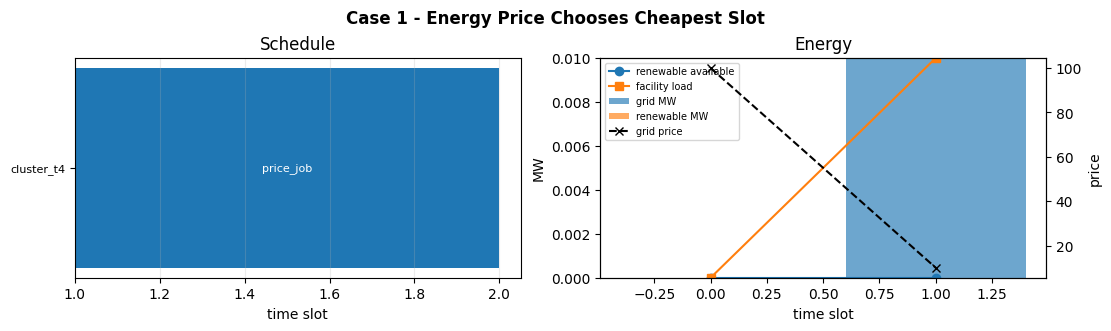

,job_id,category,workload_family,assigned_cluster,cluster_role,cluster_gpu_type,start_hour,duration,power,gpu_type_required,gpu_count_required,cpu_required,memory_required_gb
0,price_job,tiny_gpu_job,tiny_absurd_check,cluster_t4,tiny_test_cluster,T4,1,1,0.01,T4,1,4.0,16.0


In [3]:
jobs_df = tiny_jobs([{"job_id": "price_job", "earliest_start": 0, "latest_start": 1}])
hourly_df = tiny_hourly(grid_price=[100.0, 10.0])
clusters_df = tiny_clusters([{}])
result = solve_tiny_case(jobs_df=jobs_df, hourly_df=hourly_df, clusters_df=clusters_df)
schedule = result["schedule"]
observed_start = int(schedule.loc[0, "start_hour"])
record_result(
    "energy_price_cheapest_slot",
    observed_start == 1,
    "job starts at cheaper slot 1",
    f"job starts at slot {observed_start}",
)
schedule
plot_tiny_case("Case 1 - Energy Price Chooses Cheapest Slot", schedule, result["hourly_results"], result["cluster_results"])
schedule


## Case 2 - Renewable Preference

One job can run at slot 0 or slot 1. Grid prices are equal, but renewable energy is available only at slot 0 and renewable price is lower. The expected result is slot 0.


,job_id,category,workload_family,assigned_cluster,cluster_role,cluster_gpu_type,start_hour,duration,power,gpu_type_required,gpu_count_required,cpu_required,memory_required_gb
0,renewable_job,tiny_gpu_job,tiny_absurd_check,cluster_t4,tiny_test_cluster,T4,0,1,0.01,T4,1,4.0,16.0


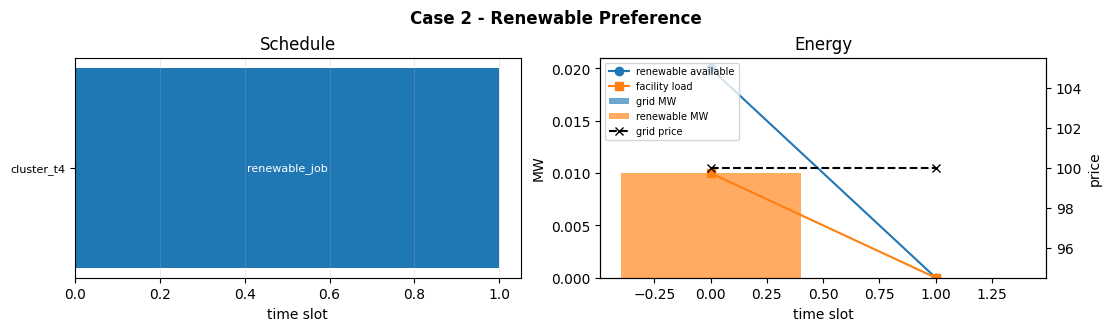

,hour,baseline_load,pue,flexible_load,it_load,total_load,facility_load,renewable_available,renewable_consumption,renewable_curtailment,grid_consumption,grid_price
0,0,0.0,1.0,0.01,0.01,0.01,0.01,0.02,0.01,0.01,0.0,100.0
1,1,0.0,1.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,100.0


In [4]:
jobs_df = tiny_jobs([{"job_id": "renewable_job", "earliest_start": 0, "latest_start": 1}])
hourly_df = tiny_hourly(grid_price=[100.0, 100.0], renewable_available=[0.020, 0.0])
clusters_df = tiny_clusters([{}])
config = ModelConfig(contracted_power=1.0, renewable_price=5.0, peak_price=1000.0, delta_t=1.0, pue=1.0)
result = solve_tiny_case(jobs_df=jobs_df, hourly_df=hourly_df, clusters_df=clusters_df, config=config)
schedule = result["schedule"]
hourly_results = result["hourly_results"]
observed_start = int(schedule.loc[0, "start_hour"])
record_result(
    "renewable_preference",
    observed_start == 0 and hourly_results.loc[0, "renewable_consumption"] > 0,
    "job starts at renewable slot 0 and consumes renewable energy",
    f"start={observed_start}, renewable_slot0={hourly_results.loc[0, 'renewable_consumption']:.4f}",
)
display(schedule)
hourly_results
plot_tiny_case("Case 2 - Renewable Preference", result["schedule"], hourly_results, result["cluster_results"])
hourly_results


## Case 3 - GPU Capacity Prevents Overlap

Two one-slot jobs can both run in slots 0 or 1. The cluster has only one GPU. The expected result is that jobs are separated across the two slots.


,job_id,category,workload_family,assigned_cluster,cluster_role,cluster_gpu_type,start_hour,duration,power,gpu_type_required,gpu_count_required,cpu_required,memory_required_gb
0,gpu_job_2,tiny_gpu_job,tiny_absurd_check,cluster_t4,tiny_test_cluster,T4,0,1,0.01,T4,1,4.0,16.0
1,gpu_job_1,tiny_gpu_job,tiny_absurd_check,cluster_t4,tiny_test_cluster,T4,1,1,0.01,T4,1,4.0,16.0


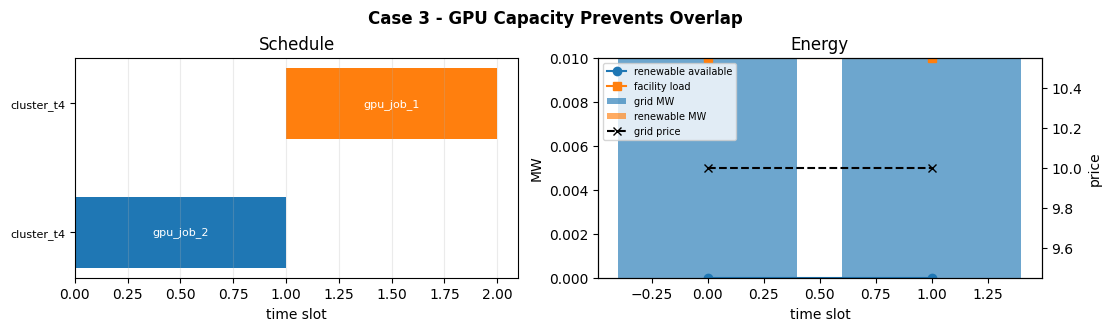

,cluster_id,cluster_role,gpu_type,hour,cluster_load,capacity,cluster_gpu_load,gpu_capacity,cluster_cpu_load,cpu_capacity,cluster_memory_load,memory_capacity_gb
0,cluster_t4,tiny_test_cluster,T4,0,0.01,0.02,1.0,1,4.0,16.0,16.0,128.0
1,cluster_t4,tiny_test_cluster,T4,1,0.01,0.02,1.0,1,4.0,16.0,16.0,128.0


In [5]:
jobs_df = tiny_jobs([
    {"job_id": "gpu_job_1", "earliest_start": 0, "latest_start": 1},
    {"job_id": "gpu_job_2", "earliest_start": 0, "latest_start": 1},
])
hourly_df = tiny_hourly(grid_price=[10.0, 10.0])
clusters_df = tiny_clusters([{"gpu_count": 1, "gpu_capacity": 1, "cpu_capacity": 16.0, "memory_capacity_gb": 128.0}])
result = solve_tiny_case(jobs_df=jobs_df, hourly_df=hourly_df, clusters_df=clusters_df)
schedule = result["schedule"]
starts = sorted(schedule["start_hour"].astype(int).tolist())
record_result(
    "gpu_capacity_prevents_overlap",
    starts == [0, 1],
    "two jobs are separated because only one GPU is available",
    f"starts={starts}",
)
display(schedule)
result["cluster_results"]
plot_tiny_case("Case 3 - GPU Capacity Prevents Overlap", schedule, result["hourly_results"], result["cluster_results"])
result["cluster_results"]


## Case 4 - GPU Type Compatibility

A job requires T4. There are two clusters: one G2 and one T4. The expected result is assignment to the T4 cluster.


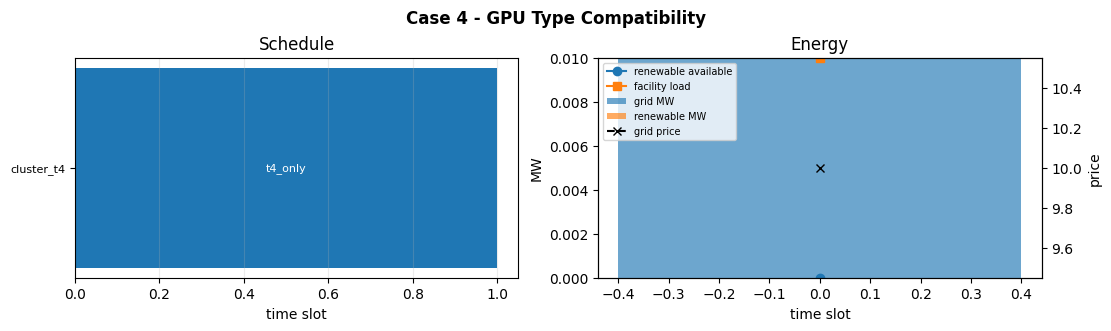

,job_id,category,workload_family,assigned_cluster,cluster_role,cluster_gpu_type,start_hour,duration,power,gpu_type_required,gpu_count_required,cpu_required,memory_required_gb
0,t4_only,tiny_gpu_job,tiny_absurd_check,cluster_t4,tiny_test_cluster,T4,0,1,0.01,T4,1,4.0,16.0


In [6]:
jobs_df = tiny_jobs([{"job_id": "t4_only", "gpu_type_required": "T4", "earliest_start": 0, "latest_start": 0}])
hourly_df = tiny_hourly(grid_price=[10.0])
clusters_df = tiny_clusters([
    {"cluster_id": "cluster_g2", "gpu_type": "G2"},
    {"cluster_id": "cluster_t4", "gpu_type": "T4"},
])
result = solve_tiny_case(jobs_df=jobs_df, hourly_df=hourly_df, clusters_df=clusters_df)
schedule = result["schedule"]
assigned_cluster = str(schedule.loc[0, "assigned_cluster"])
record_result(
    "gpu_type_compatibility",
    assigned_cluster == "cluster_t4",
    "T4 job is assigned to T4 cluster",
    f"assigned_cluster={assigned_cluster}",
)
schedule
plot_tiny_case("Case 4 - GPU Type Compatibility", schedule, result["hourly_results"], result["cluster_results"])
schedule


## Case 5 - Incompatible GPU Type Fails Fast

A job requires T4, but only a G2 cluster exists. The expected result is a build-time failure because the job has no compatible cluster.


In [7]:
jobs_df = tiny_jobs([{"job_id": "impossible_t4", "gpu_type_required": "T4", "earliest_start": 0, "latest_start": 0}])
hourly_df = tiny_hourly(grid_price=[10.0])
clusters_df = tiny_clusters([{"cluster_id": "cluster_g2", "gpu_type": "G2"}])
try:
    solve_tiny_case(jobs_df=jobs_df, hourly_df=hourly_df, clusters_df=clusters_df)
    observed = "model solved unexpectedly"
    passed = False
except ValueError as exc:
    observed = str(exc)
    passed = "no compatible cluster" in observed

record_result(
    "incompatible_gpu_fails_fast",
    passed,
    "model build fails when a job has no compatible GPU type",
    observed,
)
observed


"jobs have no compatible cluster: ['impossible_t4']"

## Case 6 - CPU and Memory Ablation

Two jobs fit GPU capacity but cannot overlap when CPU and memory constraints are enabled. If CPU and memory are disabled, the cheaper slot should attract both jobs.


,job_id,category,workload_family,assigned_cluster,cluster_role,cluster_gpu_type,start_hour,duration,power,gpu_type_required,gpu_count_required,cpu_required,memory_required_gb
0,resource_job_2,tiny_gpu_job,tiny_absurd_check,cluster_t4,tiny_test_cluster,T4,0,1,0.01,T4,1,8.0,64.0
1,resource_job_1,tiny_gpu_job,tiny_absurd_check,cluster_t4,tiny_test_cluster,T4,1,1,0.01,T4,1,8.0,64.0


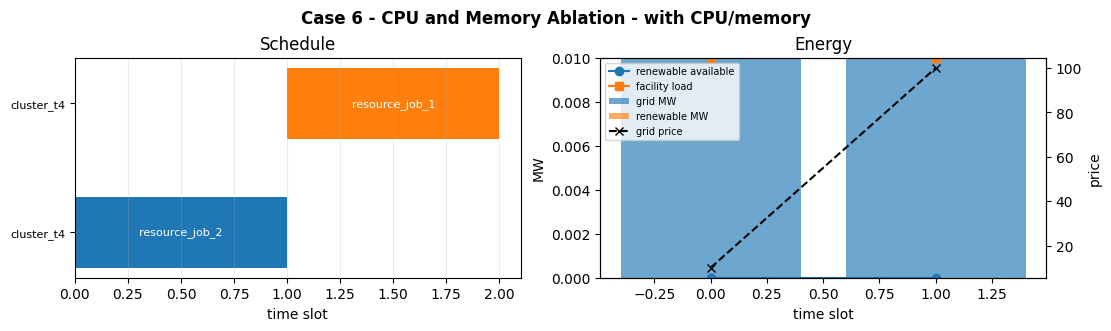

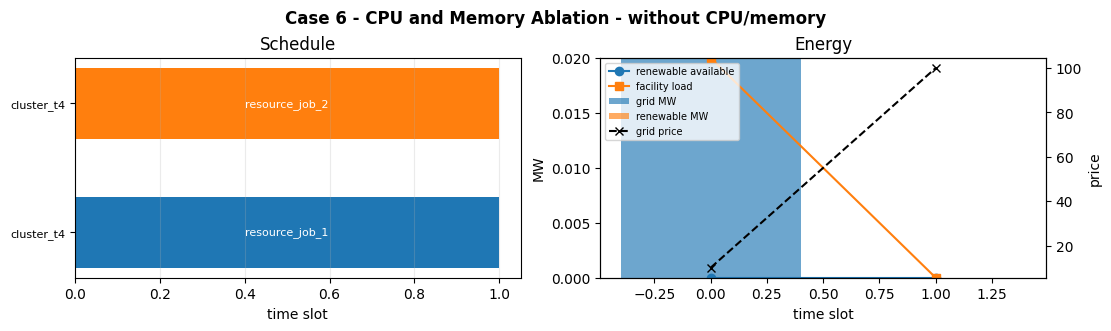

,job_id,category,workload_family,assigned_cluster,cluster_role,cluster_gpu_type,start_hour,duration,power,gpu_type_required,gpu_count_required,cpu_required,memory_required_gb
0,resource_job_1,tiny_gpu_job,tiny_absurd_check,cluster_t4,tiny_test_cluster,T4,0,1,0.01,T4,1,8.0,64.0
1,resource_job_2,tiny_gpu_job,tiny_absurd_check,cluster_t4,tiny_test_cluster,T4,0,1,0.01,T4,1,8.0,64.0


In [8]:
jobs_df = tiny_jobs([
    {"job_id": "resource_job_1", "earliest_start": 0, "latest_start": 1, "cpu_required": 8.0, "memory_required_gb": 64.0},
    {"job_id": "resource_job_2", "earliest_start": 0, "latest_start": 1, "cpu_required": 8.0, "memory_required_gb": 64.0},
])
hourly_df = tiny_hourly(grid_price=[10.0, 100.0])
clusters_df = tiny_clusters([{"gpu_count": 2, "gpu_capacity": 2, "cpu_capacity": 8.0, "memory_capacity_gb": 64.0}])
with_resources = solve_tiny_case(jobs_df=jobs_df, hourly_df=hourly_df, clusters_df=clusters_df)
without_resources = solve_tiny_case(
    jobs_df=jobs_df,
    hourly_df=hourly_df,
    clusters_df=clusters_df,
    enforce_cpu_constraints=False,
    enforce_memory_constraints=False,
)
starts_with = sorted(with_resources["schedule"]["start_hour"].astype(int).tolist())
starts_without = sorted(without_resources["schedule"]["start_hour"].astype(int).tolist())
record_result(
    "cpu_memory_ablation",
    starts_with == [0, 1] and starts_without == [0, 0],
    "enabled constraints separate jobs; disabled constraints allow cheap-slot overlap",
    f"enabled={starts_with}, disabled={starts_without}",
)
display(with_resources["schedule"])
without_resources["schedule"]
plot_tiny_case("Case 6 - CPU and Memory Ablation - with CPU/memory", with_resources["schedule"], with_resources["hourly_results"], with_resources["cluster_results"])
plot_tiny_case("Case 6 - CPU and Memory Ablation - without CPU/memory", without_resources["schedule"], without_resources["hourly_results"], without_resources["cluster_results"])
without_resources["schedule"]


## Case 7 - PUE Scales IT Load Into Facility Load

One 0.01 MW IT job runs with PUE = 1.5. The expected facility load is 0.015 MW.


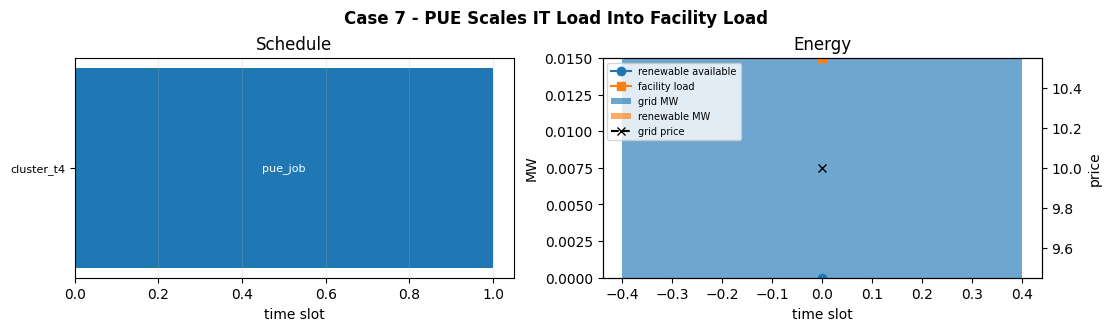

,hour,baseline_load,pue,flexible_load,it_load,total_load,facility_load,renewable_available,renewable_consumption,renewable_curtailment,grid_consumption,grid_price
0,0,0.0,1.5,0.01,0.01,0.015,0.015,0.0,0.0,0.0,0.015,10.0


In [9]:
jobs_df = tiny_jobs([{"job_id": "pue_job", "power": 0.010, "earliest_start": 0, "latest_start": 0}])
hourly_df = tiny_hourly(grid_price=[10.0])
clusters_df = tiny_clusters([{}])
config = ModelConfig(contracted_power=1.0, renewable_price=0.0, peak_price=1000.0, delta_t=1.0, pue=1.5)
result = solve_tiny_case(jobs_df=jobs_df, hourly_df=hourly_df, clusters_df=clusters_df, config=config)
hourly_results = result["hourly_results"]
it_load = float(hourly_results.loc[0, "it_load"])
facility_load = float(hourly_results.loc[0, "total_load"])
record_result(
    "pue_scales_facility_load",
    abs(it_load - 0.010) < 1e-9 and abs(facility_load - 0.015) < 1e-9,
    "IT load 0.010 MW becomes facility load 0.015 MW with PUE 1.5",
    f"it_load={it_load:.4f}, facility_load={facility_load:.4f}",
)
hourly_results
plot_tiny_case("Case 7 - PUE Scales IT Load Into Facility Load", result["schedule"], hourly_results, result["cluster_results"])
hourly_results


## Case 8 - Peak Penalty Discourages Overlap

Two jobs can overlap or separate. Grid prices are equal, so energy cost alone is indifferent. Contracted power is low enough that overlap creates a peak penalty. The expected result is separation.


,job_id,category,workload_family,assigned_cluster,cluster_role,cluster_gpu_type,start_hour,duration,power,gpu_type_required,gpu_count_required,cpu_required,memory_required_gb
0,peak_job_1,tiny_gpu_job,tiny_absurd_check,cluster_t4,tiny_test_cluster,T4,0,1,0.01,T4,1,4.0,16.0
1,peak_job_2,tiny_gpu_job,tiny_absurd_check,cluster_t4,tiny_test_cluster,T4,1,1,0.01,T4,1,4.0,16.0


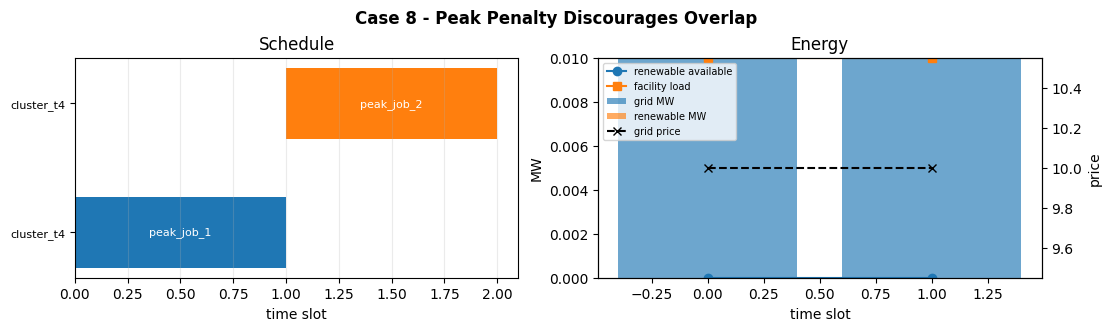

,hour,baseline_load,pue,flexible_load,it_load,total_load,facility_load,renewable_available,renewable_consumption,renewable_curtailment,grid_consumption,grid_price
0,0,0.0,1.0,0.01,0.01,0.01,0.01,0.0,0.0,0.0,0.01,10.0
1,1,0.0,1.0,0.01,0.01,0.01,0.01,0.0,0.0,0.0,0.01,10.0


In [10]:
jobs_df = tiny_jobs([
    {"job_id": "peak_job_1", "earliest_start": 0, "latest_start": 1, "power": 0.010},
    {"job_id": "peak_job_2", "earliest_start": 0, "latest_start": 1, "power": 0.010},
])
hourly_df = tiny_hourly(grid_price=[10.0, 10.0])
clusters_df = tiny_clusters([{"capacity": 0.020, "gpu_count": 2, "gpu_capacity": 2, "cpu_capacity": 16.0, "memory_capacity_gb": 128.0}])
config = ModelConfig(contracted_power=0.010, renewable_price=0.0, peak_price=10_000.0, delta_t=1.0, pue=1.0)
result = solve_tiny_case(jobs_df=jobs_df, hourly_df=hourly_df, clusters_df=clusters_df, config=config)
schedule = result["schedule"]
hourly_results = result["hourly_results"]
starts = sorted(schedule["start_hour"].astype(int).tolist())
peak_grid = float(hourly_results["grid_consumption"].max())
record_result(
    "peak_penalty_discourages_overlap",
    starts == [0, 1] and abs(peak_grid - 0.010) < 1e-9,
    "jobs are separated to avoid grid import above contracted power",
    f"starts={starts}, peak_grid={peak_grid:.4f}",
)
display(schedule)
hourly_results
plot_tiny_case("Case 8 - Peak Penalty Discourages Overlap", result["schedule"], hourly_results, result["cluster_results"])
hourly_results


## Case 9 - Battery Shifts Energy From Cheap Slot To Expensive Slot

The job is fixed in the expensive second slot. A battery is available, and the first slot is much cheaper. The expected behavior is charge at slot 0 and discharge at slot 1.


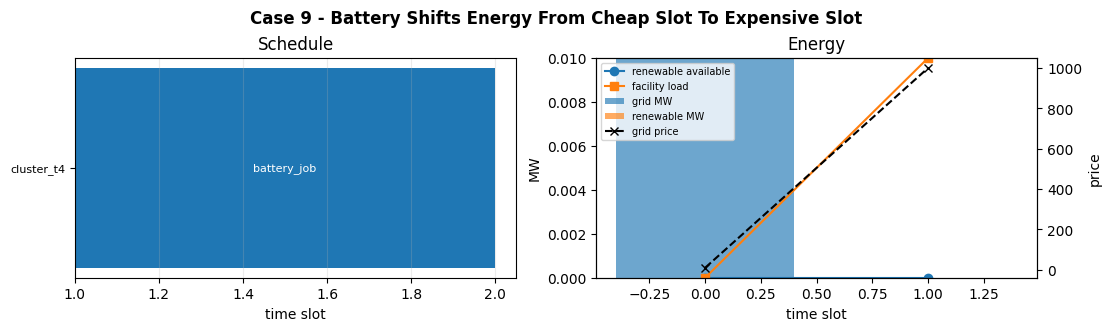

,hour,baseline_load,pue,flexible_load,it_load,total_load,facility_load,renewable_available,renewable_consumption,renewable_curtailment,grid_consumption,grid_price,battery_charge,battery_discharge,battery_soc
0,0,0.0,1.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.01,10.0,0.01,0.00,0.01
1,1,0.0,1.0,0.01,0.01,0.01,0.01,0.0,0.0,0.0,0.00,1000.0,0.00,0.01,0.00


In [11]:
jobs_df = tiny_jobs([{"job_id": "battery_job", "earliest_start": 1, "latest_start": 1, "power": 0.010}])
hourly_df = tiny_hourly(grid_price=[10.0, 1000.0])
clusters_df = tiny_clusters([{}])
config = ModelConfig(
    contracted_power=1.0,
    renewable_price=0.0,
    peak_price=1000.0,
    delta_t=1.0,
    pue=1.0,
    battery_power_capacity=0.010,
    battery_energy_capacity=0.010,
    battery_initial_soc=0.0,
    battery_charge_efficiency=1.0,
    battery_discharge_efficiency=1.0,
)
result = solve_tiny_case(jobs_df=jobs_df, hourly_df=hourly_df, clusters_df=clusters_df, config=config)
hourly_results = result["hourly_results"]
charge_0 = float(hourly_results.loc[0, "battery_charge"])
discharge_1 = float(hourly_results.loc[1, "battery_discharge"])
grid_1 = float(hourly_results.loc[1, "grid_consumption"])
record_result(
    "battery_shifts_cheap_to_expensive",
    charge_0 > 0.009 and discharge_1 > 0.009 and grid_1 < 1e-9,
    "battery charges at cheap slot 0 and discharges at expensive slot 1",
    f"charge_0={charge_0:.4f}, discharge_1={discharge_1:.4f}, grid_1={grid_1:.4f}",
)
hourly_results
plot_tiny_case("Case 9 - Battery Shifts Energy From Cheap Slot To Expensive Slot", result["schedule"], hourly_results, result["cluster_results"])
hourly_results


## Case 10 - Two Jobs Share Cheapest Slot Because They Fit

Two jobs can run in slot 0 or slot 1. Slot 0 is cheaper and the cluster has enough GPU, CPU, memory, and power capacity for both. The expected result is both jobs run at slot 0.


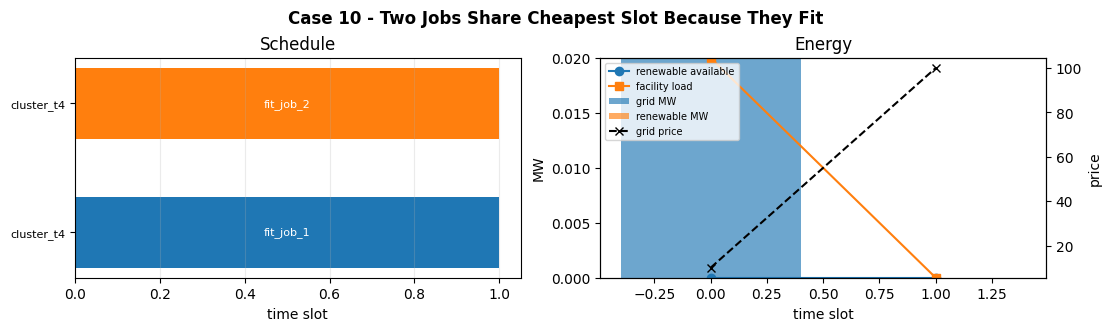

,job_id,category,workload_family,assigned_cluster,cluster_role,cluster_gpu_type,start_hour,duration,power,gpu_type_required,gpu_count_required,cpu_required,memory_required_gb
0,fit_job_1,tiny_gpu_job,tiny_absurd_check,cluster_t4,tiny_test_cluster,T4,0,1,0.01,T4,1,4.0,16.0
1,fit_job_2,tiny_gpu_job,tiny_absurd_check,cluster_t4,tiny_test_cluster,T4,0,1,0.01,T4,1,4.0,16.0


In [12]:
jobs_df = tiny_jobs([
    {"job_id": "fit_job_1", "earliest_start": 0, "latest_start": 1, "power": 0.010},
    {"job_id": "fit_job_2", "earliest_start": 0, "latest_start": 1, "power": 0.010},
])
hourly_df = tiny_hourly(grid_price=[10.0, 100.0])
clusters_df = tiny_clusters([{"capacity": 0.030, "gpu_count": 2, "gpu_capacity": 2, "cpu_capacity": 16.0, "memory_capacity_gb": 128.0}])
result = solve_tiny_case(jobs_df=jobs_df, hourly_df=hourly_df, clusters_df=clusters_df)
schedule = result["schedule"]
starts = sorted(schedule["start_hour"].astype(int).tolist())
record_result(
    "two_jobs_share_cheapest_slot_when_they_fit",
    starts == [0, 0],
    "both jobs go to cheaper slot 0 because capacity allows overlap",
    f"starts={starts}",
)
plot_tiny_case("Case 10 - Two Jobs Share Cheapest Slot Because They Fit", schedule, result["hourly_results"], result["cluster_results"])
schedule


## Case 11 - Duration Occupies Multiple Consecutive Slots

One two-slot job can start at slot 0 or slot 1. Slot 1 and 2 are cheaper than slot 0. The expected result is start at slot 1, proving duration is handled as a consecutive active interval.


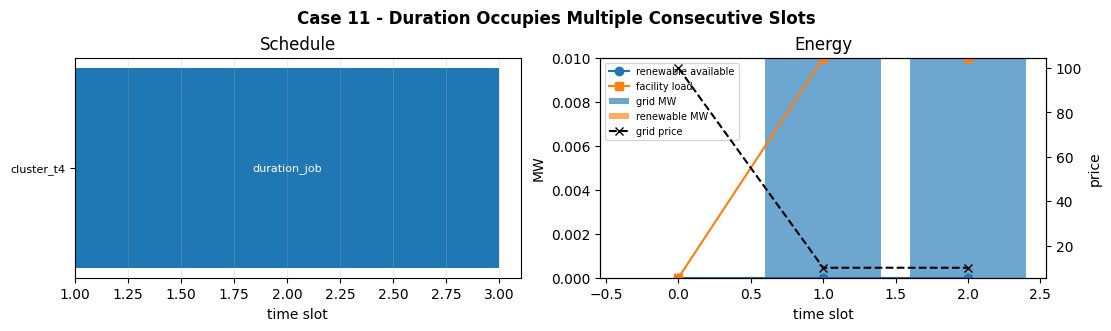

,job_id,category,workload_family,assigned_cluster,cluster_role,cluster_gpu_type,start_hour,duration,power,gpu_type_required,gpu_count_required,cpu_required,memory_required_gb
0,duration_job,tiny_gpu_job,tiny_absurd_check,cluster_t4,tiny_test_cluster,T4,1,2,0.01,T4,1,4.0,16.0


In [13]:
jobs_df = tiny_jobs([{"job_id": "duration_job", "duration": 2, "earliest_start": 0, "latest_start": 1}])
hourly_df = tiny_hourly(grid_price=[100.0, 10.0, 10.0])
clusters_df = tiny_clusters([{}])
result = solve_tiny_case(jobs_df=jobs_df, hourly_df=hourly_df, clusters_df=clusters_df)
schedule = result["schedule"]
observed_start = int(schedule.loc[0, "start_hour"])
active_load_slots = result["hourly_results"].loc[result["hourly_results"]["facility_load"] > 1e-9, "hour"].astype(int).tolist()
record_result(
    "duration_consecutive_slots",
    observed_start == 1 and active_load_slots == [1, 2],
    "two-slot job starts at 1 and is active in slots 1 and 2",
    f"start={observed_start}, active_load_slots={active_load_slots}",
)
plot_tiny_case("Case 11 - Duration Occupies Multiple Consecutive Slots", schedule, result["hourly_results"], result["cluster_results"])
schedule


## Case 12 - Deadline Restricts Access To Cheaper Future Slot

A job would prefer a cheaper future slot, but its latest start is slot 0. The expected result is start at slot 0 despite slot 1 being cheaper.


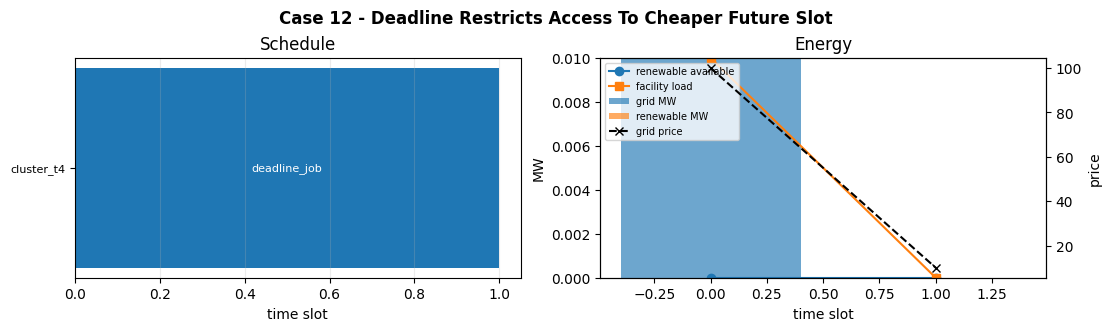

,job_id,category,workload_family,assigned_cluster,cluster_role,cluster_gpu_type,start_hour,duration,power,gpu_type_required,gpu_count_required,cpu_required,memory_required_gb
0,deadline_job,tiny_gpu_job,tiny_absurd_check,cluster_t4,tiny_test_cluster,T4,0,1,0.01,T4,1,4.0,16.0


In [14]:
jobs_df = tiny_jobs([{"job_id": "deadline_job", "earliest_start": 0, "latest_start": 0}])
hourly_df = tiny_hourly(grid_price=[100.0, 10.0])
clusters_df = tiny_clusters([{}])
result = solve_tiny_case(jobs_df=jobs_df, hourly_df=hourly_df, clusters_df=clusters_df)
schedule = result["schedule"]
observed_start = int(schedule.loc[0, "start_hour"])
record_result(
    "deadline_restricts_cheaper_future_slot",
    observed_start == 0,
    "job starts at slot 0 because latest_start forbids cheaper slot 1",
    f"start={observed_start}",
)
plot_tiny_case("Case 12 - Deadline Restricts Access To Cheaper Future Slot", schedule, result["hourly_results"], result["cluster_results"])
schedule


## Case 13 - Pipe-Separated GPU Compatibility Allows Multiple Types

One job can run on either T4 or G2. The T4 cluster is unavailable because its GPU capacity is already consumed by a fixed T4 job. The flexible job should use the G2 cluster.


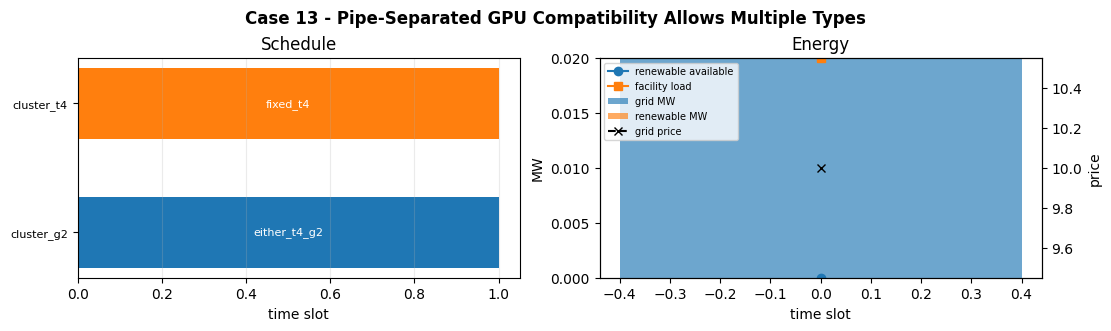

,job_id,category,workload_family,assigned_cluster,cluster_role,cluster_gpu_type,start_hour,duration,power,gpu_type_required,gpu_count_required,cpu_required,memory_required_gb
0,either_t4_g2,tiny_gpu_job,tiny_absurd_check,cluster_g2,tiny_test_cluster,G2,0,1,0.01,T4|G2,1,4.0,16.0
1,fixed_t4,tiny_gpu_job,tiny_absurd_check,cluster_t4,tiny_test_cluster,T4,0,1,0.01,T4,1,4.0,16.0


In [15]:
jobs_df = tiny_jobs([
    {"job_id": "fixed_t4", "gpu_type_required": "T4", "earliest_start": 0, "latest_start": 0, "gpu_count_required": 1},
    {"job_id": "either_t4_g2", "gpu_type_required": "T4|G2", "earliest_start": 0, "latest_start": 0, "gpu_count_required": 1},
])
hourly_df = tiny_hourly(grid_price=[10.0])
clusters_df = tiny_clusters([
    {"cluster_id": "cluster_t4", "gpu_type": "T4", "gpu_count": 1, "gpu_capacity": 1, "capacity": 0.020},
    {"cluster_id": "cluster_g2", "gpu_type": "G2", "gpu_count": 1, "gpu_capacity": 1, "capacity": 0.020},
])
result = solve_tiny_case(jobs_df=jobs_df, hourly_df=hourly_df, clusters_df=clusters_df)
schedule = result["schedule"]
assignment = dict(zip(schedule["job_id"], schedule["assigned_cluster"], strict=True))
record_result(
    "pipe_gpu_compatibility_allows_multiple_types",
    assignment["fixed_t4"] == "cluster_t4" and assignment["either_t4_g2"] == "cluster_g2",
    "T4-only job uses T4 and flexible T4|G2 job uses G2 because T4 GPU is full",
    str(assignment),
)
plot_tiny_case("Case 13 - Pipe-Separated GPU Compatibility Allows Multiple Types", schedule, result["hourly_results"], result["cluster_results"])
schedule


## Case 14 - Renewable Limit Forces Residual Grid Use

One job requires 0.02 MW facility load and renewable availability is only 0.01 MW. The expected result is 0.01 MW renewable and 0.01 MW grid consumption.


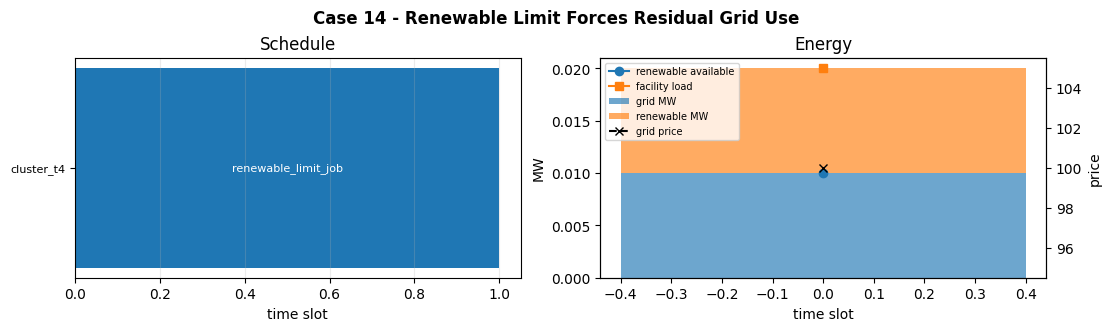

,hour,baseline_load,pue,flexible_load,it_load,total_load,facility_load,renewable_available,renewable_consumption,renewable_curtailment,grid_consumption,grid_price
0,0,0.0,1.0,0.02,0.02,0.02,0.02,0.01,0.01,0.0,0.01,100.0


In [16]:
jobs_df = tiny_jobs([{"job_id": "renewable_limit_job", "power": 0.020, "earliest_start": 0, "latest_start": 0}])
hourly_df = tiny_hourly(grid_price=[100.0], renewable_available=[0.010])
clusters_df = tiny_clusters([{"capacity": 0.030}])
config = ModelConfig(contracted_power=1.0, renewable_price=5.0, peak_price=1000.0, delta_t=1.0, pue=1.0)
result = solve_tiny_case(jobs_df=jobs_df, hourly_df=hourly_df, clusters_df=clusters_df, config=config)
hourly_results = result["hourly_results"]
renewable = float(hourly_results.loc[0, "renewable_consumption"])
grid = float(hourly_results.loc[0, "grid_consumption"])
record_result(
    "renewable_limit_forces_grid_residual",
    abs(renewable - 0.010) < 1e-9 and abs(grid - 0.010) < 1e-9,
    "renewable capped at 0.010 MW and remaining 0.010 MW comes from grid",
    f"renewable={renewable:.4f}, grid={grid:.4f}",
)
plot_tiny_case("Case 14 - Renewable Limit Forces Residual Grid Use", result["schedule"], hourly_results, result["cluster_results"])
hourly_results


## Case 15 - Battery Disabled Has No Battery Variables In Results

The same fixed expensive-slot job is solved without battery capacity. The expected result is no battery result columns and grid serves the expensive slot.


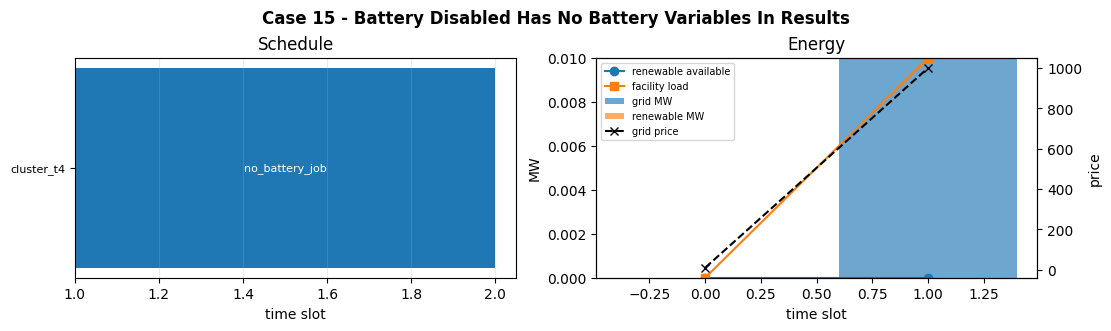

,hour,baseline_load,pue,flexible_load,it_load,total_load,facility_load,renewable_available,renewable_consumption,renewable_curtailment,grid_consumption,grid_price
0,0,0.0,1.0,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.00,10.0
1,1,0.0,1.0,0.01,0.01,0.01,0.01,0.0,0.0,0.0,0.01,1000.0


In [17]:
jobs_df = tiny_jobs([{"job_id": "no_battery_job", "earliest_start": 1, "latest_start": 1, "power": 0.010}])
hourly_df = tiny_hourly(grid_price=[10.0, 1000.0])
clusters_df = tiny_clusters([{}])
config = ModelConfig(contracted_power=1.0, renewable_price=0.0, peak_price=1000.0, delta_t=1.0, pue=1.0)
result = solve_tiny_case(jobs_df=jobs_df, hourly_df=hourly_df, clusters_df=clusters_df, config=config)
hourly_results = result["hourly_results"]
no_battery_columns = not {"battery_charge", "battery_discharge", "battery_soc"}.intersection(hourly_results.columns)
grid_1 = float(hourly_results.loc[1, "grid_consumption"])
record_result(
    "battery_disabled_has_no_battery_variables",
    no_battery_columns and abs(grid_1 - 0.010) < 1e-9,
    "no battery result columns and expensive-slot demand is served by grid",
    f"no_battery_columns={no_battery_columns}, grid_1={grid_1:.4f}",
)
plot_tiny_case("Case 15 - Battery Disabled Has No Battery Variables In Results", result["schedule"], hourly_results, result["cluster_results"])
hourly_results


## Summary

All checks should pass. If one fails, the notebook should be read as a formulation-debugging tool: either the mathematical expectation is wrong, the implementation has a bug, or the tiny instance has multiple optima and needs sharper prices/capacities.


In [18]:
summary_df = pd.DataFrame(RESULTS)
summary_df.to_csv(PROJECT_ROOT / "experiments" / "tiny_absurd_formulation_checks.csv", index=False)
summary_df


,case,passed,expected,observed
0,energy_price_cheapest_slot,True,job starts at cheaper slot 1,job starts at slot 1
1,renewable_preference,True,job starts at renewable slot 0 and consumes re...,"start=0, renewable_slot0=0.0100"
2,gpu_capacity_prevents_overlap,True,two jobs are separated because only one GPU is...,"starts=[0, 1]"
3,gpu_type_compatibility,True,T4 job is assigned to T4 cluster,assigned_cluster=cluster_t4
4,incompatible_gpu_fails_fast,True,model build fails when a job has no compatible...,jobs have no compatible cluster: ['impossible_...
5,cpu_memory_ablation,True,enabled constraints separate jobs; disabled co...,"enabled=[0, 1], disabled=[0, 0]"
6,pue_scales_facility_load,True,IT load 0.010 MW becomes facility load 0.015 M...,"it_load=0.0100, facility_load=0.0150"
7,peak_penalty_discourages_overlap,True,jobs are separated to avoid grid import above ...,"starts=[0, 1], peak_grid=0.0100"
8,battery_shifts_cheap_to_expensive,True,battery charges at cheap slot 0 and discharges...,"charge_0=0.0100, discharge_1=0.0100, grid_1=0...."
9,two_jobs_share_cheapest_slot_when_they_fit,True,both jobs go to cheaper slot 0 because capacit...,"starts=[0, 0]"
